# Part III — Variational Autoencoder (VAE) with LSTM Encoder

**Dataset:** MNIST (28×28 images treated as sequences of 28 time steps)

| Component | Architecture |
|---|---|
| **Encoder** | LSTM(input=28, hidden=128) → FC heads → `latent_dim` |
| **Sampling** | (reparameterization trick) |
| **Decoder** | FC: `latent_dim` → 256 → 512 → 784 → Sigmoid → reshape (28×28) |
| **Loss** | ELBO = BCE reconstruction + KL divergence |

## 1. Imports

In [2]:
import os
import struct
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 2. Load MNIST Data

In [3]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        _, n, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
    return images.reshape(n, rows, cols).astype(np.float32) / 255.0

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        _, n = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels.astype(np.int64)

DATA_DIR = os.path.join(os.getcwd(), 'MNIST')

X_train = load_mnist_images(os.path.join(DATA_DIR, 'train-images.idx3-ubyte'))
y_train = load_mnist_labels(os.path.join(DATA_DIR, 'train-labels.idx1-ubyte'))
X_test  = load_mnist_images(os.path.join(DATA_DIR, 't10k-images.idx3-ubyte'))
y_test  = load_mnist_labels(os.path.join(DATA_DIR, 't10k-labels.idx1-ubyte'))

print(f"Train: {X_train.shape}  Test: {X_test.shape}")

BATCH_SIZE = 128
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)),
    batch_size=BATCH_SIZE, shuffle=False
)

Train: (60000, 28, 28)  Test: (10000, 28, 28)


## 3. Task 1 — LSTM Encoder

The encoder reads the image as a sequence of 28 rows (time steps).  
The final hidden state `h_last` is projected to two vectors

In [4]:
LATENT_DIM  = 20
HIDDEN_SIZE = 128

class LSTMEncoder(nn.Module):
    """
    Input : (batch, seq_len=28, input_size=28)
    Output: mu, log_var — each (batch, LATENT_DIM)
    """
    def __init__(self, input_size=28, hidden_size=HIDDEN_SIZE, latent_dim=LATENT_DIM):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc_mu   = nn.Linear(hidden_size, latent_dim)
        self.fc_logv = nn.Linear(hidden_size, latent_dim)

    def forward(self, x):
        # x: (batch, 28, 28)
        _, (h_n, _) = self.lstm(x)   # h_n: (1, batch, hidden_size)
        h_last = h_n.squeeze(0)       # (batch, hidden_size)
        mu      = self.fc_mu(h_last)
        log_var = self.fc_logv(h_last)
        return mu, log_var

# Quick shape check
_enc = LSTMEncoder()
_x   = torch.zeros(4, 28, 28)
_mu, _lv = _enc(_x)
print(f"Encoder  input : {_x.shape}")
print(f"         mu    : {_mu.shape}")
print(f"         log_v : {_lv.shape}")

Encoder  input : torch.Size([4, 28, 28])
         mu    : torch.Size([4, 20])
         log_v : torch.Size([4, 20])


## 4. Task 2 — Fully Connected Decoder

The decoder takes a latent vector **z** sampled via the reparameterization trick and reconstructs the 784-dim image.

In [5]:
class FCDecoder(nn.Module):
    """
    Input : z — (batch, LATENT_DIM)
    Output: x_recon — (batch, 28, 28), values in [0, 1]
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),
        )

    def forward(self, z):
        out = self.net(z)                 # (batch, 784)
        return out.view(-1, 28, 28)       # (batch, 28, 28)

# Quick shape check
_dec = FCDecoder()
_z   = torch.zeros(4, LATENT_DIM)
print(f"Decoder  input : {_z.shape}")
print(f"         output: {_dec(_z).shape}")

Decoder  input : torch.Size([4, 20])
         output: torch.Size([4, 28, 28])


## 5. VAE — Full Model + Loss

In [6]:
class VAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.encoder = LSTMEncoder(latent_dim=latent_dim)
        self.decoder = FCDecoder(latent_dim=latent_dim)

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)          # ε ~ N(0, I)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def generate(self, n_samples=16):
        """Sample z ~ N(0,I) and decode."""
        with torch.no_grad():
            z = torch.randn(n_samples, LATENT_DIM, device=device)
            return self.decoder(z)


def vae_loss(x_recon, x, mu, log_var):
    # Reconstruction: pixel-wise BCE, summed over pixels, averaged over batch
    recon = F.binary_cross_entropy(x_recon, x, reduction='sum') / x.size(0)
    # KL: -½ Σ(1 + log σ² - μ² - σ²)
    kl = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    return recon + kl, recon, kl


vae = VAE().to(device)
print(vae)
total_params = sum(p.numel() for p in vae.parameters())
print(f"\nTotal parameters: {total_params:,}")

VAE(
  (encoder): LSTMEncoder(
    (lstm): LSTM(28, 128, batch_first=True)
    (fc_mu): Linear(in_features=128, out_features=20, bias=True)
    (fc_logv): Linear(in_features=128, out_features=20, bias=True)
  )
  (decoder): FCDecoder(
    (net): Sequential(
      (0): Linear(in_features=20, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=784, bias=True)
      (5): Sigmoid()
    )
  )
)

Total parameters: 625,208


## 6. Training

In [7]:
EPOCHS = 20
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

history = {'loss': [], 'recon': [], 'kl': []}

for epoch in range(1, EPOCHS + 1):
    vae.train()
    total_loss = total_recon = total_kl = 0.0

    for Xb, _ in train_loader:
        Xb = Xb.to(device)                          # (batch, 28, 28)

        x_recon, mu, log_var = vae(Xb)
        loss, recon, kl = vae_loss(x_recon, Xb, mu, log_var)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        n = Xb.size(0)
        total_loss  += loss.item()  * n
        total_recon += recon.item() * n
        total_kl    += kl.item()    * n

    N = len(train_loader.dataset)
    avg_loss  = total_loss  / N
    avg_recon = total_recon / N
    avg_kl    = total_kl    / N

    history['loss'].append(avg_loss)
    history['recon'].append(avg_recon)
    history['kl'].append(avg_kl)

    print(f"Epoch {epoch:2d}/{EPOCHS} | Loss: {avg_loss:.2f} "
          f"| Recon: {avg_recon:.2f} | KL: {avg_kl:.2f}")

Epoch  1/20 | Loss: 195.53 | Recon: 191.84 | KL: 3.69
Epoch  2/20 | Loss: 146.93 | Recon: 136.99 | KL: 9.93
Epoch  3/20 | Loss: 130.22 | Recon: 118.19 | KL: 12.03
Epoch  4/20 | Loss: 123.35 | Recon: 110.21 | KL: 13.14
Epoch  5/20 | Loss: 119.36 | Recon: 105.73 | KL: 13.63
Epoch  6/20 | Loss: 116.55 | Recon: 102.43 | KL: 14.12
Epoch  7/20 | Loss: 114.19 | Recon: 99.40 | KL: 14.79
Epoch  8/20 | Loss: 112.10 | Recon: 96.75 | KL: 15.35
Epoch  9/20 | Loss: 110.16 | Recon: 94.28 | KL: 15.88
Epoch 10/20 | Loss: 108.58 | Recon: 92.25 | KL: 16.32
Epoch 11/20 | Loss: 107.28 | Recon: 90.67 | KL: 16.61
Epoch 12/20 | Loss: 106.37 | Recon: 89.57 | KL: 16.80
Epoch 13/20 | Loss: 105.54 | Recon: 88.62 | KL: 16.92
Epoch 14/20 | Loss: 104.89 | Recon: 87.83 | KL: 17.06
Epoch 15/20 | Loss: 104.38 | Recon: 87.22 | KL: 17.16
Epoch 16/20 | Loss: 103.88 | Recon: 86.64 | KL: 17.24
Epoch 17/20 | Loss: 103.43 | Recon: 86.11 | KL: 17.31
Epoch 18/20 | Loss: 103.05 | Recon: 85.63 | KL: 17.42
Epoch 19/20 | Loss: 102.

## 7. Training Loss Curves

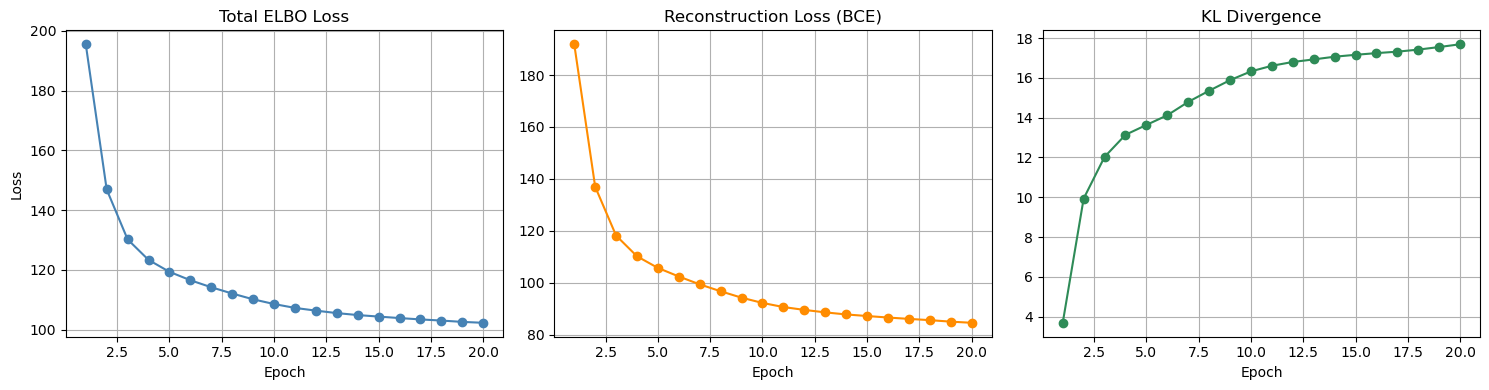

Saved task3_vae_training_curves.png


In [8]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['loss'],  marker='o', color='steelblue')
axes[0].set_title('Total ELBO Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

axes[1].plot(epochs_range, history['recon'], marker='o', color='darkorange')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].set_xlabel('Epoch'); axes[1].grid(True)

axes[2].plot(epochs_range, history['kl'],    marker='o', color='seagreen')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch'); axes[2].grid(True)

plt.tight_layout()
plt.savefig('task3_vae_training_curves.png', dpi=150)
plt.show()
print("Saved task3_vae_training_curves.png")

## 8. Reconstruction Quality

Pass test images through the full VAE (encode → sample → decode) and compare originals vs. reconstructions.

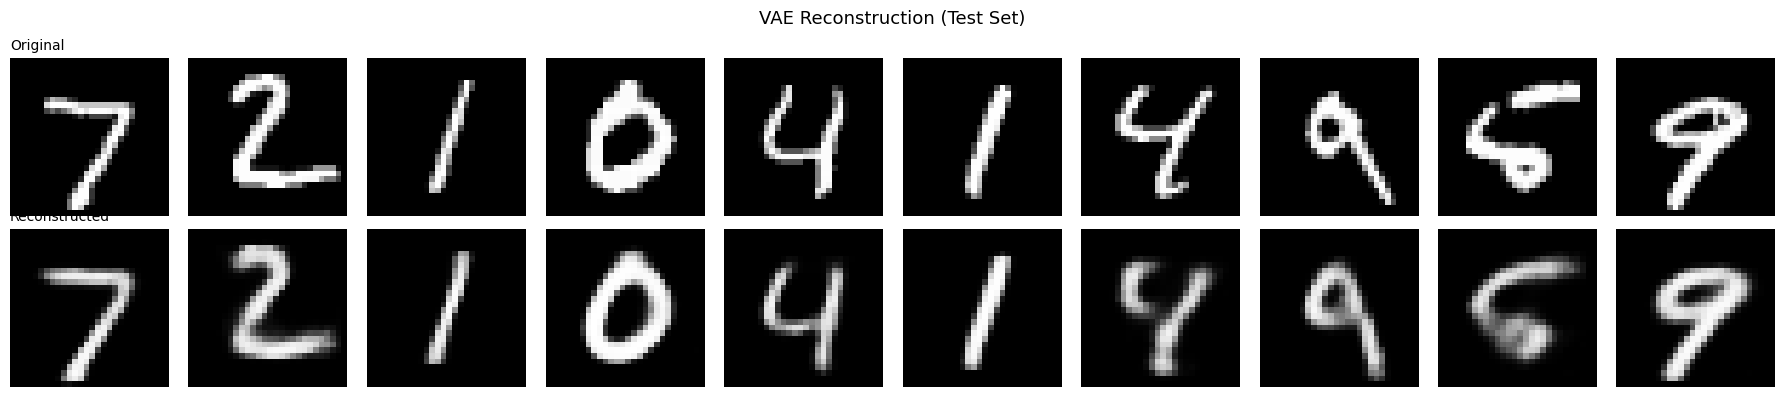

Saved task3_vae_reconstructions.png


In [9]:
vae.eval()
n_show = 10

# Grab one batch from the test set
X_sample, _ = next(iter(test_loader))
X_sample = X_sample[:n_show].to(device)

with torch.no_grad():
    x_recon, _, _ = vae(X_sample)

originals    = X_sample.cpu().numpy()
reconstructed = x_recon.cpu().numpy()

fig, axes = plt.subplots(2, n_show, figsize=(18, 4))
for i in range(n_show):
    axes[0, i].imshow(originals[i],     cmap='gray', vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i], cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].axis('off')

axes[0, 0].set_title('Original',       fontsize=10, loc='left')
axes[1, 0].set_title('Reconstructed',  fontsize=10, loc='left')
plt.suptitle('VAE Reconstruction (Test Set)', fontsize=13)
plt.tight_layout()
plt.savefig('task3_vae_reconstructions.png', dpi=150)
plt.show()
print("Saved task3_vae_reconstructions.png")

## 9. Task 3 — Generate New Samples from N(0, I)

Sample random latent vectors **z ~ N(0, I)** (no input image) and pass them through the decoder to generate new digit images.

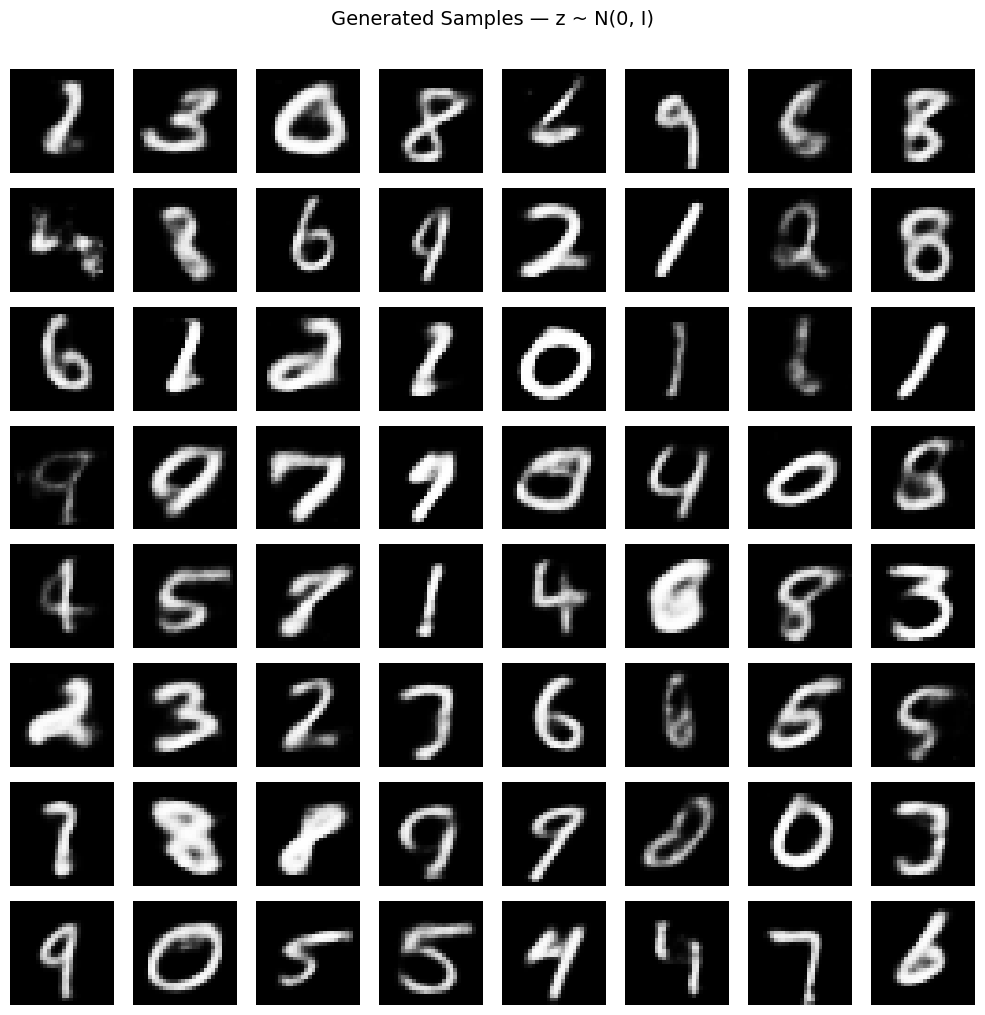

Saved task3_vae_generated_samples.png


In [11]:
vae.eval()
N_GEN = 64   # generate 64 samples arranged in an 8×8 grid

generated = vae.generate(n_samples=N_GEN).cpu().numpy()  # (64, 28, 28)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i], cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.suptitle('Generated Samples — z ~ N(0, I)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('task3_vae_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved task3_vae_generated_samples.png")